<img align="left" style="padding-right:10px;" src="figuras/banner_cd.png">

# Proyecto de Machine Learning

In [5]:
# Importar librerias
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np

## 1. Obtención y visualización de los datos

In [6]:
#Cargar el archivo datos/german_train_validation.txt
df = pd.read_csv('datos/train_val.csv')
df

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length,class
0,10.82,12.83,0.8256,5.180,2.630,4.853,5.089,Canadian
1,11.75,13.52,0.8082,5.444,2.678,4.378,5.310,Canadian
2,10.83,12.96,0.8099,5.278,2.641,5.182,5.185,Canadian
3,18.81,16.29,0.8906,6.272,3.693,3.237,6.053,Rosa
4,17.32,15.91,0.8599,6.064,3.403,3.824,5.922,Rosa
...,...,...,...,...,...,...,...,...
160,20.16,17.03,0.8735,6.513,3.773,1.910,6.185,Rosa
161,17.55,15.66,0.8991,5.791,3.690,5.366,5.661,Rosa
162,12.36,13.19,0.8923,5.076,3.042,3.220,4.605,Kama
163,18.98,16.66,0.8590,6.549,3.670,3.691,6.498,Rosa


In [7]:
df['class'].value_counts()

class
Canadian    55
Rosa        55
Kama        55
Name: count, dtype: int64

In [8]:
# Mostrar los primeras filas
df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length,class
0,10.82,12.83,0.8256,5.180,2.630,4.853,5.089,Canadian
1,11.75,13.52,0.8082,5.444,2.678,4.378,5.310,Canadian
2,10.83,12.96,0.8099,5.278,2.641,5.182,5.185,Canadian
3,18.81,16.29,0.8906,6.272,3.693,3.237,6.053,Rosa
4,17.32,15.91,0.8599,6.064,3.403,3.824,5.922,Rosa


In [9]:
# Mostrar el número de filas y columnas
df.shape

(165, 8)

In [10]:
# Mostrar el tipo de variables
df.dtypes

area                     float64
perimeter                float64
compactness              float64
kernel_length            float64
kernel_width             float64
asymmetry_coefficient    float64
kernel_groove_length     float64
class                     object
dtype: object

In [11]:
#Principales parámetros estadísticos 
df.describe()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,14.892970,14.584182,0.870515,5.640006,3.262152,3.705698,5.416436
std,2.938413,1.310065,0.024661,0.444961,0.382892,1.543428,0.495693
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.300000,13.470000,0.856000,5.267000,2.941000,2.461000,5.046000
50%,14.430000,14.350000,0.873400,5.527000,3.258000,3.638000,5.222000
75%,17.320000,15.660000,0.888000,5.980000,3.552000,4.873000,5.879000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


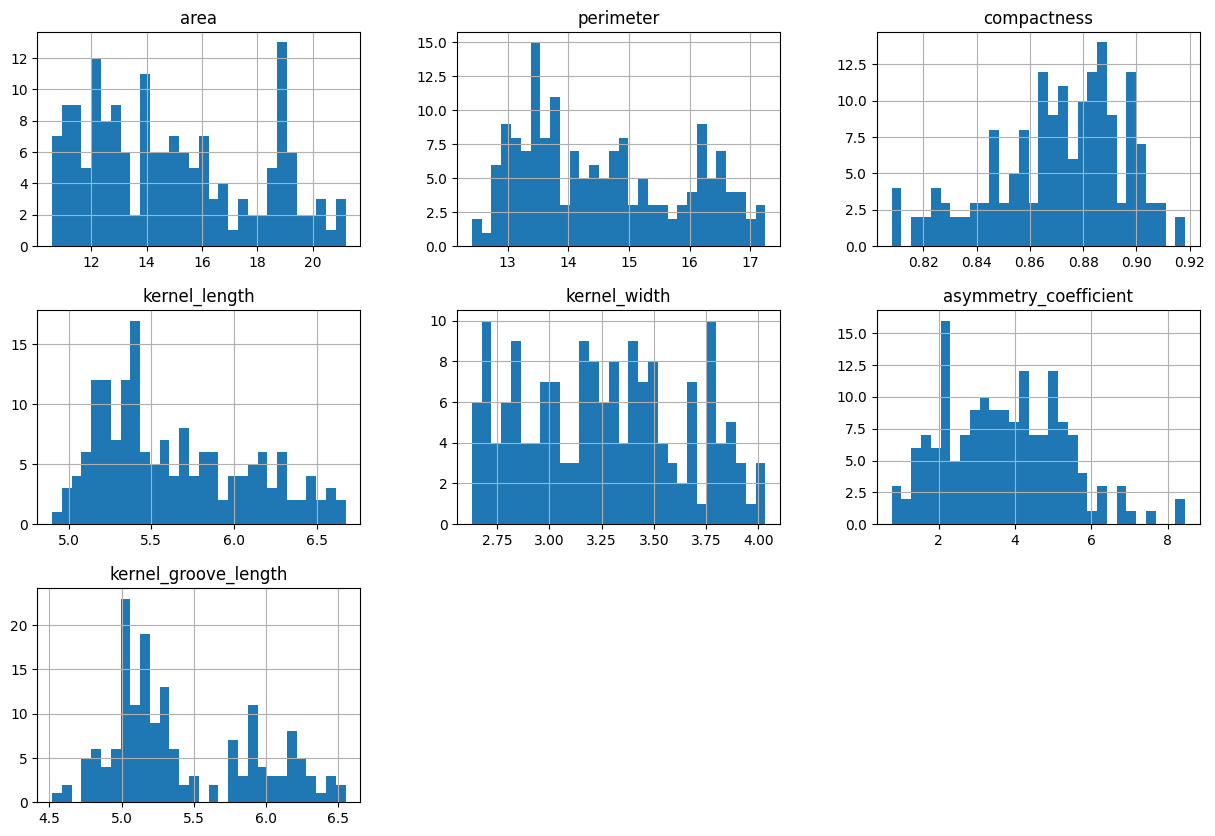

In [12]:
# Histograma de todas las variables  
df.hist(bins=30, figsize=(15,10));
plt.show();

In [13]:
df.columns

Index(['area', 'perimeter', 'compactness', 'kernel_length', 'kernel_width',
       'asymmetry_coefficient', 'kernel_groove_length', 'class'],
      dtype='object')

In [14]:
numeric_list = [ 'area',  'compactness', 'kernel_length',
       'asymmetry_coefficient', 'kernel_groove_length' ]

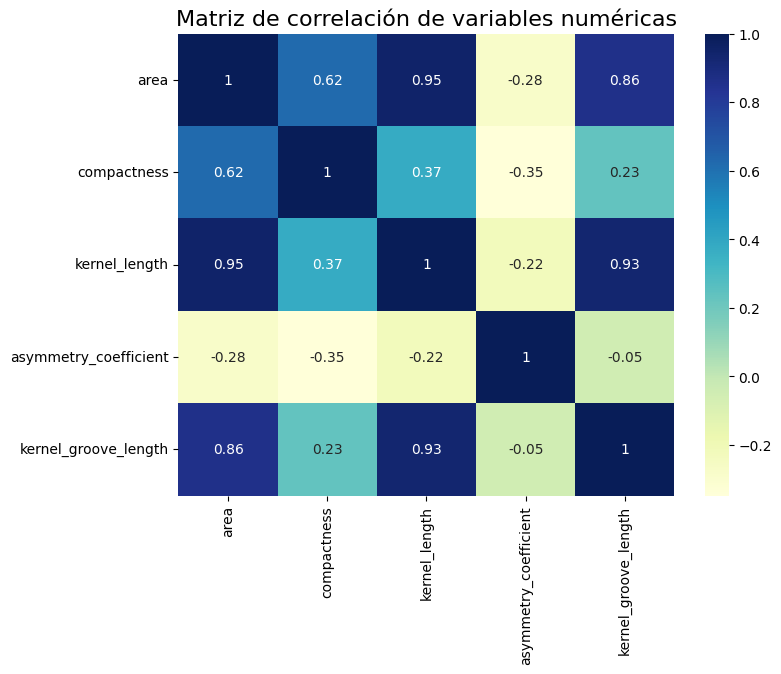

In [15]:
# Matriz correlación visual
import seaborn as sn
correlation_matrix = df[numeric_list].corr()
plt.figure(figsize=(8,6))
sn.heatmap(correlation_matrix, annot=True, cmap='YlGnBu')
plt.title('Matriz de correlación de variables numéricas', fontsize=16)
plt.show()

## 2. Preparación de los datos y funciones

In [16]:
# Preparación de datos
from sklearn.model_selection import train_test_split

In [17]:
## Verificando que no existan valores nulos
df.isnull().any().any()

np.False_

#### División general de los datos


<img  align="middle" style="width:350px;" src="figuras/ml_diagrama3.jpg">



* **X**: Datos sin el diagnostico es decir sin la columna "target"
* **y**: Datos con el diagnostico es decir con la columna "target"

Muestras de entrenamiento y prueba
* **X_train**: este será el grupo de entrenamiento
* **X_test**: este será el  grupo de prueba
* **y_train**: este será el target para el grupo de entrenamiento
* **y_test**: este será el target para el grupo de prueba

In [18]:
#Crear X (Quitar la columna o campo 24)
X =df.drop('class', axis=1)
X.head(2)

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length
0,10.82,12.83,0.8256,5.180,2.630,4.853,5.089
1,11.75,13.52,0.8082,5.444,2.678,4.378,5.310


In [19]:
# Crear y (Valor de de la columna "target")
y=df['class']
y.head()

0    Canadian
1    Canadian
2    Canadian
3        Rosa
4        Rosa
Name: class, dtype: object

In [20]:
# Dividir los datos para entrenamiento y prueba. Con un factor 82%
X_train , X_test, y_train, y_test = train_test_split(X, y, train_size=0.82, random_state=42)
print( 'X_train :' , X_train.shape )
print( 'X_test :' , X_test.shape )
print( 'y_train :' , y_train.shape )
print( 'y_test :' ,  y_test.shape )
print( 'df 100% :' ,  df.shape[0]   )
print( 'len(X_train) / 3 :' ,  len(X_train) / 3 )


X_train : (135, 7)
X_test : (30, 7)
y_train : (135,)
y_test : (30,)
df 100% : 165
len(X_train) / 3 : 45.0


### Pipeline

<img src="figuras/pipeline.jpg" align="middle" style="width:400px;" />

In [21]:
# Modulos importantes
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [22]:
# Mostrando columnas
df.columns

Index(['area', 'perimeter', 'compactness', 'kernel_length', 'kernel_width',
       'asymmetry_coefficient', 'kernel_groove_length', 'class'],
      dtype='object')

In [23]:
# Crear la lista de  viriables numericas  numeric_list 
numeric_list = [ 'area',  'compactness', 'kernel_length',
       'asymmetry_coefficient', 'kernel_groove_length' ]

In [24]:
# Crear el pipeline de preprocesamiento para datos numéricos  numeric_transformer
numeric_transformer = Pipeline(  steps = [ ('scaler',  StandardScaler()  )  ]   )

In [25]:
# Definir los transformadores
transformer = ColumnTransformer( [ ('num', numeric_transformer, numeric_list  )  ]  )

# 3. Implementación de Modelos

## Primer modelo: Clasificador Decision Tree (DT)

## a) DT sin tunning

In [26]:
# Módulos del Modelo
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


In [27]:
# modelo DecisionTreeClassifier llamado DT_Classifier
DT_Classifier = DecisionTreeClassifier()

In [28]:
# Parametros del modelo DecisionTreeClassifier()
DT_Classifier.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [29]:
modelo_DT = Pipeline ( [  ('transformer',transformer) ,  ('DT_Classifier',DT_Classifier)     ]  )

In [30]:
modelo_DT.fit(X_train, y_train)

,steps,"[('transformer', ...), ('DT_Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
modelo_DT.score(X_test, y_test)

0.8666666666666667

## b) DT con tunning

In [32]:
# Definir los parametros con el diccionario params utilizando:
max_depth = [ 5 , 8, 10  , 12 , 30 ,40 ,50]
min_samples_leaf = [2,5,10,   14,  ]
min_samples_split = [ 2,5,8, 10]
parametros = {   'DT_Classifier__max_depth': max_depth ,
                 'DT_Classifier__min_samples_leaf': min_samples_leaf ,
                 'DT_Classifier__min_samples_split': min_samples_split
             }

In [33]:
# Ajuste de los parametros max_depth y min_samples_leaf con  GridSearchCV
from sklearn.model_selection import GridSearchCV
grid_DT = GridSearchCV(  modelo_DT , parametros , 
                       cv=5 , n_jobs=-1 , verbose=10  )

In [34]:
# Ajuste del modelo usando todas las posibles combinaciones de parametros 
grid_DT.fit(X_train, y_train)

Fitting 5 folds for each of 112 candidates, totalling 560 fits


[CV 1/5; 1/112] START DT_Classifier__max_depth=5, DT_Classifier__min_samples_leaf=2, DT_Classifier__min_samples_split=2
[CV 1/5; 1/112] END DT_Classifier__max_depth=5, DT_Classifier__min_samples_leaf=2, DT_Classifier__min_samples_split=2;, score=1.000 total time=   0.0s
[CV 4/5; 2/112] START DT_Classifier__max_depth=5, DT_Classifier__min_samples_leaf=2, DT_Classifier__min_samples_split=5
[CV 4/5; 1/112] START DT_Classifier__max_depth=5, DT_Classifier__min_samples_leaf=2, DT_Classifier__min_samples_split=2
[CV 4/5; 2/112] END DT_Classifier__max_depth=5, DT_Classifier__min_samples_leaf=2, DT_Classifier__min_samples_split=5;, score=0.815 total time=   0.0s
[CV 5/5; 2/112] START DT_Classifier__max_depth=5, DT_Classifier__min_samples_leaf=2, DT_Classifier__min_samples_split=5
[CV 4/5; 1/112] END DT_Classifier__max_depth=5, DT_Classifier__min_samples_leaf=2, DT_Classifier__min_samples_split=2;, score=0.815 total time=   0.0s
[CV 5/5; 2/112] END DT_Classifier__max_depth=5, DT_Classifier__min_

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'DT_Classifier__max_depth': [5, 8, ...], 'DT_Classifier__min_samples_leaf': [2, 5, ...], 'DT_Classifier__min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [35]:
#Encontrar los mejores parametros con best_params_
grid_DT.best_params_

{'DT_Classifier__max_depth': 5,
 'DT_Classifier__min_samples_leaf': 5,
 'DT_Classifier__min_samples_split': 2}

In [49]:
# Ajustar el modelo con los nuevos parametros nombrandolo como  DT_Classifier_tunned
DT_Classifier_tunned = DecisionTreeClassifier( max_depth =5,
                                               min_samples_leaf=5,
                                               min_samples_split=2
                                                )

In [50]:
# Definiendo el modelo_DT con su pipeline
modelo_DT_tunned = Pipeline ( [  ('transformer',transformer) , 
                                ('DT_Classifier_tunned',DT_Classifier_tunned)     ]  )

In [51]:
#  Ajustar el modelo
modelo_DT_tunned.fit(X_train, y_train);

In [52]:
# Predicción
y_predict = modelo_DT_tunned.predict(X_test)
y_predict[:20]

array(['Rosa', 'Canadian', 'Canadian', 'Kama', 'Kama', 'Kama', 'Canadian',
       'Kama', 'Kama', 'Kama', 'Kama', 'Rosa', 'Kama', 'Kama', 'Canadian',
       'Canadian', 'Canadian', 'Kama', 'Rosa', 'Canadian'], dtype=object)

In [53]:
# Datos de y_test
y_test.values[:20]

array(['Rosa', 'Canadian', 'Canadian', 'Kama', 'Canadian', 'Canadian',
       'Canadian', 'Kama', 'Kama', 'Kama', 'Kama', 'Rosa', 'Kama', 'Kama',
       'Kama', 'Canadian', 'Canadian', 'Kama', 'Rosa', 'Canadian'],
      dtype=object)

In [54]:
# Comparación
np.equal(  y_predict , y_test.values  ).sum()

np.int64(27)

In [55]:
# Score 
len(y_predict)

30

In [56]:
np.equal(  y_predict , y_test.values  ).sum()/ len(y_predict)

np.float64(0.9)

In [57]:
# Score con la fución score
modelo_DT_tunned.score(X_test, y_test)

0.9

### Guardar el modelo entrenado

In [58]:
import joblib

In [59]:
#Exportar el modelo
#joblib.dump(modelo, 'Ubicación del archivo .joblib')
joblib.dump(modelo_DT_tunned, 'modelos/modelo_DT_tunned_semillas.joblib')

['modelos/modelo_DT_tunned_semillas.joblib']

In [60]:
# Importar librerias
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score

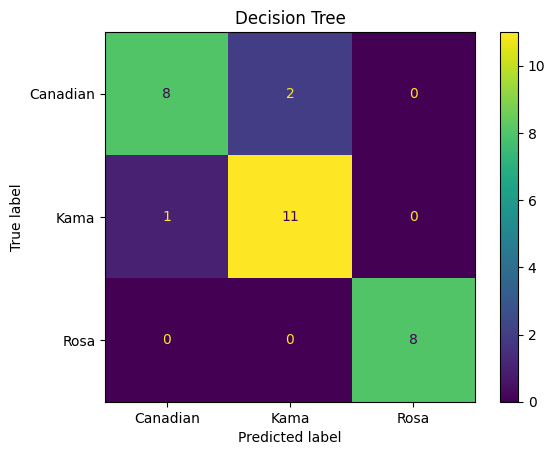

In [61]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions_DT_tunned = modelo_DT_tunned.predict(X_test)
cm_DT_tunned = confusion_matrix(y_test, predictions_DT_tunned, labels=modelo_DT_tunned.classes_)
disp_DT_tunned  = ConfusionMatrixDisplay(confusion_matrix=cm_DT_tunned, display_labels=modelo_DT_tunned.classes_)
disp_DT_tunned.plot()
plt.title('Decision Tree')
plt.show()